## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [3]:
X.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0


Noted that our X has 12 columns and further EDA will be done on month and day to chnge the strings to interger. The columns will help predict the target

In [4]:
y.head()

,area
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


For y is area which represents the burnt part of the forest.

In [5]:
y.info()
y.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   area    517 non-null    float64
dtypes: float64(1)
memory usage: 4.2 KB


,area
count,517.000000
mean,12.847292
std,63.655818
min,0.000000
25%,0.000000
50%,0.520000
75%,6.570000
max,1090.840000


In [6]:
# importing libraries that will be in use
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [7]:
print(X.isnull().sum())
print(y.isnull().sum())

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
dtype: int64
area    0
dtype: int64


The dataset was examined for missing values in both the predictor variables and target variable. No missing values were found, hence, no deletion is needed 

In [8]:
df = pd.concat([X,y], axis = 1)

combined the X and y variables together

In [9]:
df.duplicated().sum()

np.int64(4)

In [10]:
# checking on original rows and it's duplicates
df[df.duplicated(keep=False)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


In [11]:
# removing the duplicates
df = df.drop_duplicates()

the three code above we checked for the duplicates and found four of them, confirmed the original row and it's duplicate and then we droped the duplicates

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

<function matplotlib.pyplot.show(close=None, block=None)>

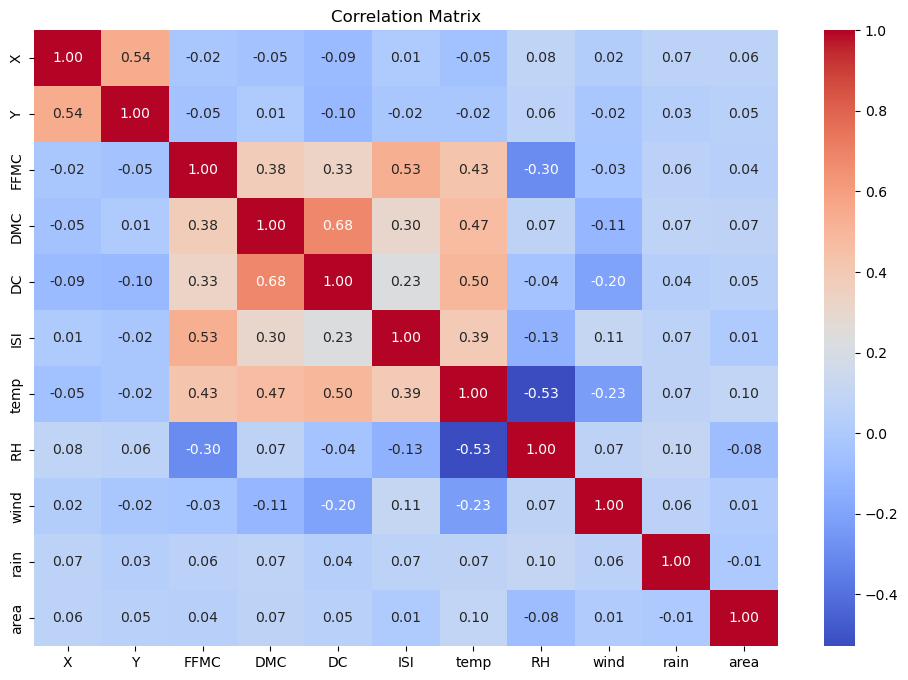

In [12]:
#Analyzing the correlation and visualizing it's heatmap
#Calculating corr
corr = df.select_dtypes(include='number').corr()
#plot corr heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show

The correlation matrix shows that most predictors have weak linear relationships with fire area('area'). Temperature has the strongest positive correlation(0.10), while relative humidity has the strongest negative correlation(-0.08).
Some predictore are moderately correlated with each other, particularly DMC and DC (0.68), which may indicate multicollinearity that will be investigated during modelling.

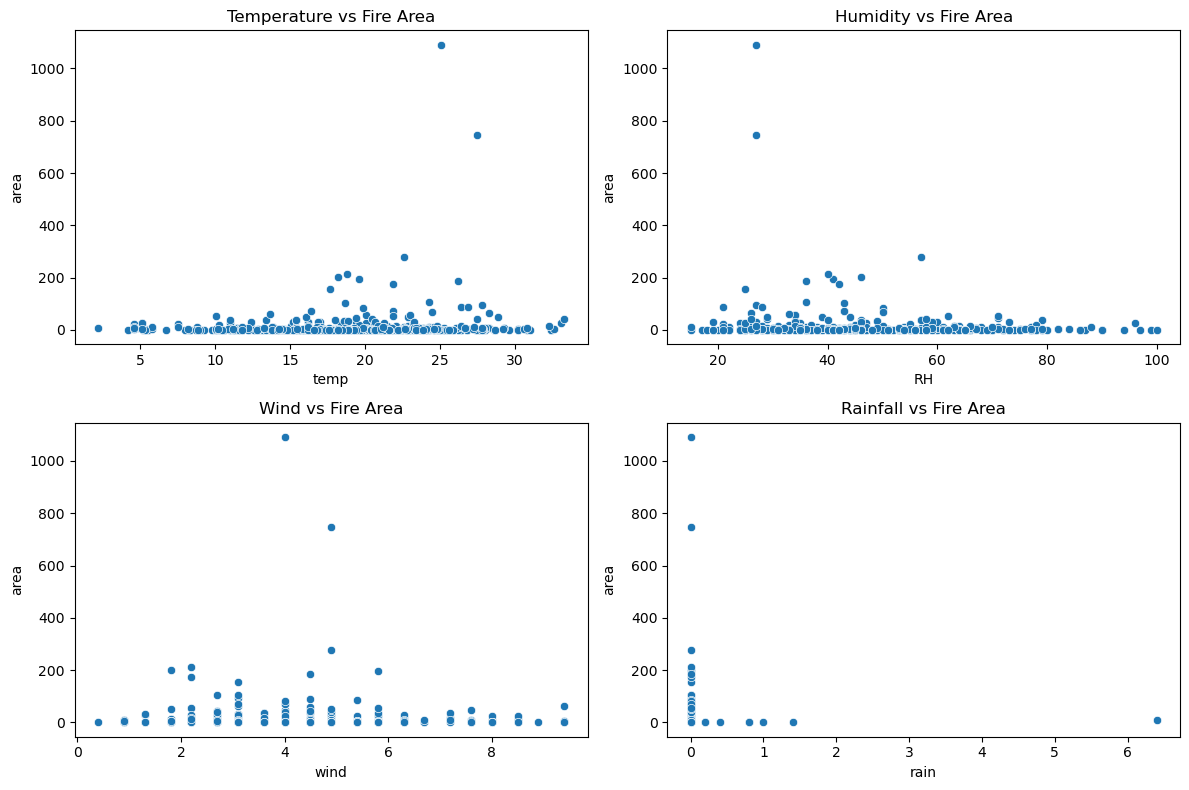

In [13]:
# Scatterplots on weather variables
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.scatterplot(data=df,x='temp',y='area',ax=axes[0,0])
axes[0,0].set_title('Temperature vs Fire Area')

sns.scatterplot(data=df,x='RH',y='area',ax=axes[0,1])
axes[0,1].set_title('Humidity vs Fire Area')

sns.scatterplot(data=df,x='wind',y='area',ax=axes[1,0])
axes[1,0].set_title('Wind vs Fire Area')

sns.scatterplot(data=df,x='rain',y='area',ax=axes[1,1])
axes[1,1].set_title('Rainfall vs Fire Area')

plt.tight_layout()
plt.show()

The scatterplots show that temperature,humidity,wind and rainfall have no linear relationship with fire area. Most observations have relatively small burned areas, while a few observations have large values, indicating that the  target variable is highly skewed

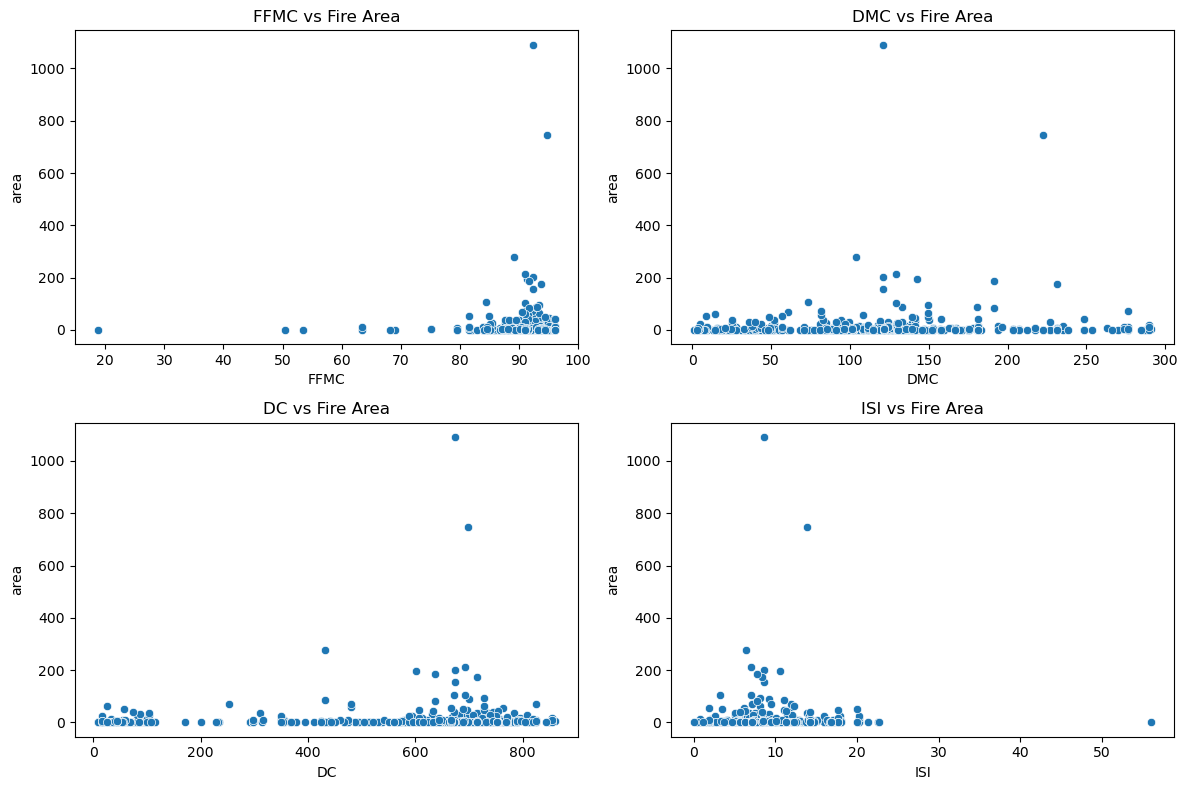

In [14]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.scatterplot(data=df,x='FFMC',y='area',ax=axes[0,0])
axes[0,0].set_title('FFMC vs Fire Area')

sns.scatterplot(data=df,x='DMC',y='area',ax=axes[0,1])
axes[0,1].set_title('DMC vs Fire Area')

sns.scatterplot(data=df,x='DC',y='area',ax=axes[1,0])
axes[1,0].set_title('DC vs Fire Area')

sns.scatterplot(data=df,x='ISI',y='area',ax=axes[1,1])
axes[1,1].set_title('ISI vs Fire Area')

plt.tight_layout()
plt.show()

The scatterplots show weak or no clear linear relationships between FFMC, DMC, DC, ISI and fire area. Most observations have small burned areas, while a few observations have extremley large values. This is consistent with the correlation analysis, where all four variables had weak correlations with 'area'

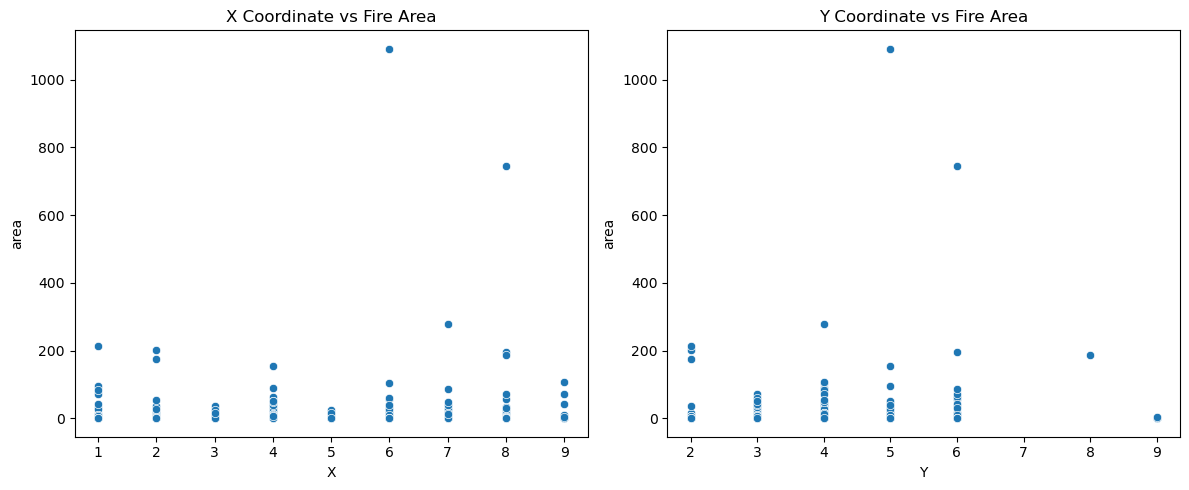

In [15]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.scatterplot(data=df,x='X',y='area',ax=axes[0])
axes[0].set_title('X Coordinate vs Fire Area')

sns.scatterplot(data=df,x='Y',y='area',ax=axes[1])
axes[1].set_title('Y Coordinate vs Fire Area')

plt.tight_layout()
plt.show()

The scatterplots of x and y coordinates against fire show no clear linear relationship. Most observations have small burned areas across the different locations, with a few extreme fire-area values. This is consistent with the weak correlations of 0.06 for x and 0.05 for y.

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [16]:
# Fitting a baseline multiple linear regression model with key predictors
# 1.Define X and y
X = df[['X','Y','FFMC','DMC','ISI','temp','RH','wind','rain']]
y = df['area']

# 2.Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

# 3. Creating and training the model
model = LinearRegression()
model.fit(X_train,y_train)

# 4.Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate the model
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print('Baseline Multiple Linear Regression')
print('MAE:',mae)
print('MSE:',mse)
print('RMSE:',rmse)
print('R2:',r2)

Baseline Multiple Linear Regression
MAE: 15.907595793301644
MSE: 522.1596029861195
RMSE: 22.850811867111407
R2: -0.3559072716095839


The baseline multiple linear regression model produced an MAE of 15.91, RMSE of 22.85, and an R² of -0.356. The negative R² indicates that the model performs worse than using the mean fire area as a baseline prediction. This poor performance may be related to the highly skewed target variable and the weak linear relationships observed during EDA. Therefore, we will investigate nonlinear terms, transformations, interactions, and categorical variables to improve the model.

In [17]:
# Nonlinear regression model
# 1. Create a copy of the dataframe
df_nonlinear = df.copy()

# 2. Create quadratic terms
df_nonlinear['temp_squared'] = df_nonlinear['temp']**2
df_nonlinear['DMC_squared'] = df_nonlinear['DMC']**2
df_nonlinear['DC_squared'] = df_nonlinear['DC']**2

# 3.Define predictors and target
X = df_nonlinear[
    ['X','Y','FFMC','DMC','DC','ISI','temp','RH','wind','rain','temp_squared','DMC_squared','DC_squared']
]
y = df_nonlinear['area']

# 4. Split the data
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

# 5. Create and train the nonlinear model
model_nonlinear = LinearRegression()
model_nonlinear.fit(X_train,y_train)

# 6. Make predictions
y_pred_nonlinear = model_nonlinear.predict(X_test)

# 7. Evaluate the model
mae = mean_absolute_error(y_test, y_pred_nonlinear)
mse = mean_squared_error(y_test, y_pred_nonlinear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_nonlinear)

print("Nonlinear Multiple Linear Regression")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Nonlinear Multiple Linear Regression
MAE: 15.450896970037386
MSE: 501.94237380747614
RMSE: 22.4040704740785
R²: -0.30340859515442964


Quadratic terms were added for temperature, DMC, and DC to capture possible nonlinear relationships. The model showed a slight improvement compared with the baseline model. MAE decreased from 15.91 to 15.45, RMSE decreased from 22.85 to 22.40, and R² improved from -0.356 to -0.303. However, the R² remains negative, indicating that the model still performs poorly compared with a mean-based prediction.

In [18]:
# Adding interaction terms
# 1. creating the interaction term
df_nonlinear['DMC_DC'] = df_nonlinear['DMC'] * df_nonlinear['DC']

In [19]:
# 2. Define predictors and target
X = df_nonlinear[
    ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI',
     'temp', 'RH', 'wind', 'rain',
     'temp_squared', 'DMC_squared', 'DC_squared',
     'DMC_DC']
]

y = df_nonlinear['area']


# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 4. Train the model
model_interaction = LinearRegression()
model_interaction.fit(X_train, y_train)


# 5. Make predictions
y_pred_interaction = model_interaction.predict(X_test)


# 6. Evaluate
mae = mean_absolute_error(y_test, y_pred_interaction)
mse = mean_squared_error(y_test, y_pred_interaction)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_interaction)

print("Nonlinear + Interaction Regression")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Nonlinear + Interaction Regression
MAE: 15.689776002249607
MSE: 512.5285881687623
RMSE: 22.639094243559356
R²: -0.3308981308235981


An interaction term between DMC and DC was added to investigate whether their combined effect could improve the prediction of fire area. However, model performance decreased after adding the interaction. R² decreased from -0.303 to -0.331, while MAE and RMSE also increased. Therefore, the DMC × DC interaction does not improve the model and will not be retained.

In [20]:
# 1. Create quadratic terms
df['temp_squared'] = df['temp'] ** 2
df['DMC_squared'] = df['DMC'] ** 2
df['DC_squared'] = df['DC'] ** 2

# 2. Define numerical and categorical predictors
numeric_features = [
    'X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI',
    'temp', 'RH', 'wind', 'rain',
    'temp_squared', 'DMC_squared', 'DC_squared'
]
categorical_features = ['month', 'day']

# 3. Define X and y
X = df[numeric_features + categorical_features]
y = df['area']

# 4. Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Create One-Hot Encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

# 6. Encode the categorical variables
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# 7. Create and train the model
model_categorical = LinearRegression()
model_categorical.fit(X_train_encoded, y_train)

# 8. Make predictions
y_pred_categorical = model_categorical.predict(X_test_encoded)

# 9. Evaluate the model
mae = mean_absolute_error(y_test, y_pred_categorical)
mse = mean_squared_error(y_test, y_pred_categorical)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_categorical)

print("Nonlinear + Categorical Variables")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Nonlinear + Categorical Variables
MAE: 16.90977691281319
MSE: 503.17383780064023
RMSE: 22.431536679430597
R²: -0.30660637409693625


The categorical variables 'month' and 'day' were converted into indicator variables using One-Hot Encoding and added to the nonlinear regression model. However, the model performance did not improve. MAE and RMSE increased slightly, while R² decreased from -0.303 to -0.307. Therefore, the categorical variables will not be retained in the preferred regression model.

In [21]:
# creating the log_transformed target
df['log_area'] = np.log1p(df['area'])

In [22]:
# checking through heads
df[['area','log_area']].head()

,area,log_area
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [23]:
# 2. Define predictors
X = df[
    ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI',
     'temp', 'RH', 'wind', 'rain']
]

# 3. Define transformed target
y = df['log_area']

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Create and train the model
model_log = LinearRegression()
model_log.fit(X_train, y_train)

# 6. Make predictions
y_pred_log = model_log.predict(X_test)

# 7. Evaluate the model
mae = mean_absolute_error(y_test, y_pred_log)
mse = mean_squared_error(y_test, y_pred_log)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_log)

print("Log-Transformed Target Regression")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

Log-Transformed Target Regression
MAE: 1.1009232863954002
MSE: 1.6440660011483597
RMSE: 1.2822113714783376
R²: 0.015855993108340183


The target variable 'area' was log-transformed using 'log1p()' because it was highly right-skewed. The log-transformed model improved the R² from -0.303 to 0.016, changing from negative to positive. However, the model still explains only about 1.6% of the variation in log-transformed fire area, indicating that further modelling techniques are required.

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [24]:
# Fitting log-transformed model using statsmodels
import statsmodels.api as sm
# Add intercept
X_train_sm = sm.add_constant(X_train)

# Fit OLS model
ols_model = sm.OLS(y_train,X_train_sm).fit()

# Display model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9395
Date:                Tue, 01 Sep 2026   Prob (F-statistic):              0.497
Time:                        12:30:31   Log-Likelihood:                -720.65
No. Observations:                 410   AIC:                             1463.
Df Residuals:                     399   BIC:                             1507.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4954      1.573     -0.315      0.7

The OLS model using the log-transformed fire area produced an R2 of  0.023 and an adjusted R2 of -0.001, indicating very low explanatory power. The overall F-test was not statistically significant (p=0.497), and none of the individual predictors had a p-value below 0.05. The AIC was 1463 and BIC was 1507, which will be useful when comparing models. The Jarque-Bera test indicated that the residuals are not normally distributed. The large condition number (1.40*104) also suggests possible multicollinearity or numerical issues.

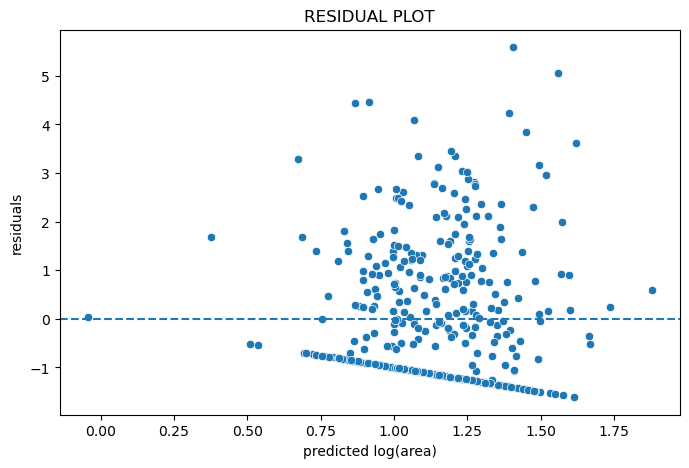

In [25]:
# Residual plot
# Get predictions from the ols model
y_pred_ols = ols_model.predict(X_train_sm)

# calculate residuals
residuals = y_train - y_pred_ols

# plot the residual
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_ols,y=residuals)

plt.axhline(y=0, linestyle='--')
plt.xlabel('predicted log(area)')
plt.ylabel('residuals')
plt.title('RESIDUAL PLOT')

plt.show()

The residuals are distributed both above and below the zero line, indicating that the model makes both underpredictions and overpredictions. However, the residuals are not completely randomly scattered and show some noticeable patterns, particularly below zero. This suggests that the model may not fully capture the relationship between the predictors and fire area.

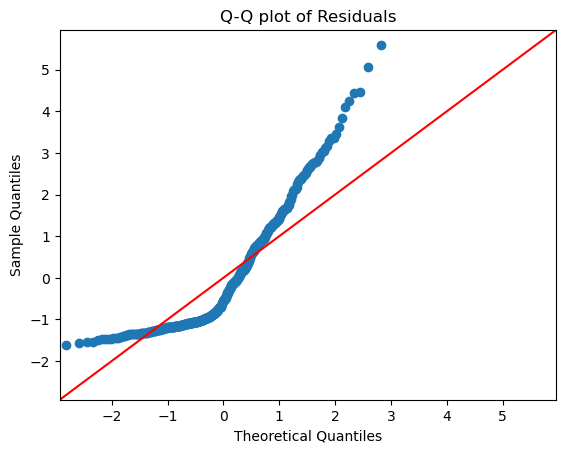

In [26]:
# Q-Q plot
sm.qqplot(ols_model.resid, line='45')
plt.title('Q-Q plot of Residuals')
plt.show()

The Q-Q plot shows that the residuals do not closely follow the reference line, particularly at the lower and upper tails. This indicates that the residuals are not normally distributed. This finding is consistent with the Jarque-Bera test, which produced a very small p-value (3.87 × 10⁻²³).

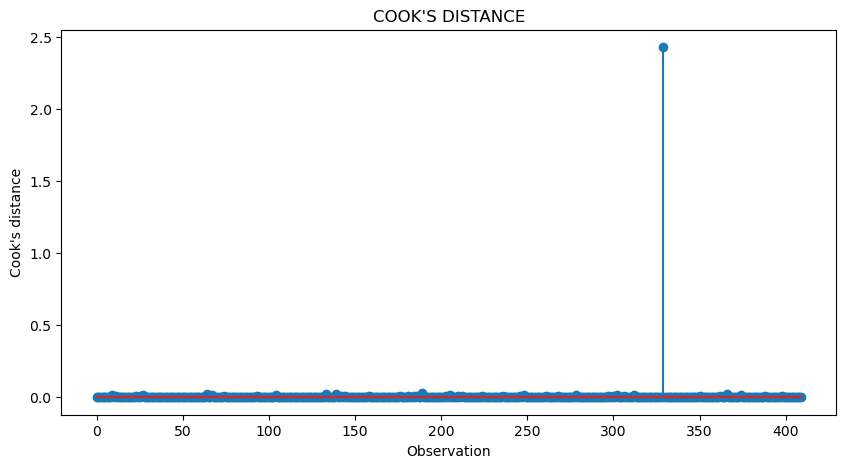

In [27]:
# COOK'S DISTANCE
#It tells us whether an individual observation has a large influence on the regression model
# Get influence measures
influence = ols_model.get_influence()

# Calculate cook's Distance
cooks_d = influence.cooks_distance[0]

#Plot cook's distance
plt.figure(figsize=(10,5))
plt.stem(range(len(cooks_d)), cooks_d)

plt.xlabel('Observation')
plt.ylabel("Cook's distance")
plt.title("COOK'S DISTANCE")
plt.show()

In [28]:
# Find the 10 observations with the highest Cook's Distance
cooks_df = pd.DataFrame({
    'Observation': range(len(cooks_d)),
    "Cook's Distance": cooks_d
})

cooks_df.sort_values(
    by="Cook's Distance",
    ascending=False
).head(10)

,Observation,Cook's Distance
329,329,2.428579
189,189,0.029252
366,366,0.022714
133,133,0.022511
139,139,0.021275
64,64,0.020252
302,302,0.017089
312,312,0.016453
278,278,0.016316
67,67,0.015424


Cook's Distance was used to identify observations that have a strong influence on the regression model. Using the rule of thumb 4/n, where n = 410, observations with Cook's Distance greater than approximately 0.0098 were flagged for further investigation. Observation 329 had a Cook's Distance of 2.43, making it the most influential observation by a large margin. Other observations also exceeded the threshold but had substantially smaller values. Influential observations will not be removed automatically because they may represent legitimate extreme wildfire events.

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [29]:
# RIDGE AND LASSO REGRESSION
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
# 1. Scale the predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Create the models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)

# 3. Fit the models
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

# 4. Make predictions
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

# 5. Calculate MSE
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)

# 6. Display MSE
print("Ridge Regression")
print("MSE:", ridge_mse)

print("\nLasso Regression")
print("MSE:", lasso_mse)

# 7. Compare coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

print("\nCoefficients:")
print(coefficients)

# 8. Model comparison
comparison = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'MSE': [ridge_mse, lasso_mse]
})

print("\nModel Comparison:")
print(comparison)

Ridge Regression
MSE: 1.6437628359434042

Lasso Regression
MSE: 1.6465070779774653

Coefficients:
  Feature     Ridge     Lasso
0       X  0.108438  0.101851
1       Y  0.008984  0.000131
2    FFMC  0.052986  0.034979
3     DMC  0.040218  0.033817
4      DC  0.056567  0.047289
5     ISI -0.116768 -0.082087
6    temp  0.110093  0.099927
7      RH -0.025534 -0.016294
8    wind  0.137240  0.117894
9    rain  0.023968  0.014867

Model Comparison:
   Model       MSE
0  Ridge  1.643763
1  Lasso  1.646507


Ridge (L2) and Lasso (L1) regression were applied after standardizing the predictors to address potential multicollinearity and improve model generalization. Ridge produced an MSE of 1.644, while Lasso produced an MSE of 1.647. Since lower MSE indicates better predictive performance, Ridge performed slightly better than Lasso. Lasso also reduced some coefficients close to zero, demonstrating its ability to perform feature selection. Overall, Ridge was the slightly better model based on test MSE, although the difference between the two models was small.

### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [30]:
# Creating the binary target
# calculating the median
median_area = df['area'].median()
print('median fire area:', median_area)

median fire area: 0.54


In [31]:
# checking for the new target
df['high_risk']=(df['area']>0.54).astype(int)

In [32]:
print(df['high_risk'].value_counts())

high_risk
0    257
1    256
Name: count, dtype: int64


In [33]:
print(df['high_risk'].value_counts(normalize=True) * 100)

high_risk
0    50.097466
1    49.902534
Name: proportion, dtype: float64


Using the median fire area of 0.54 as the threshold, 257 observations (50.10%) were classified as low risk and 256 observations (49.90%) as high risk. The two classes are almost evenly balanced, so no additional class-balancing technique is required.

In [34]:
# selecting predictors and scaling them
# Select predictors
X = df[
    ['X', 'Y', 'FFMC', 'DMC', 'DC',
     'ISI', 'temp', 'RH', 'wind', 'rain']
]

# Binary target
y = df['high_risk']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The above code creates:
1. X_train_scaled
2. X_test_scaled
3. y_train
4. y_test

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# 1. Create the Logistic Regression model
log_model = LogisticRegression(random_state=42)

# 2. Train the model
log_model.fit(X_train_scaled, y_train)

# 3. Predict probabilities
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# 4. Predict binary outcomes
y_pred = log_model.predict(X_test_scaled)

# 5. Display intercept
print("Intercept:", log_model.intercept_[0])

# 6. Display coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

print("\nCoefficients:")
print(coefficients)

# 7. Display first 10 predicted probabilities
print("\nPredicted Probabilities:")
print(y_prob[:10])

# 8. Display first 10 predicted classes
print("\nPredicted Classes:")
print(y_pred[:10])

# 9. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\nModel Performance:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nConfusion Matrix:")
print(cm)

Intercept: -0.004908774926779193

Coefficients:
  Feature  Coefficient
0       X     0.050101
1       Y     0.073130
2    FFMC     0.185076
3     DMC     0.032764
4      DC     0.149946
5     ISI    -0.076181
6    temp    -0.091312
7      RH    -0.164346
8    wind     0.143217
9    rain    -0.090405

Predicted Probabilities:
[0.47958606 0.56616953 0.56741561 0.58336672 0.49243916 0.57796872
 0.46877404 0.5206995  0.53478801 0.49529933]

Predicted Classes:
[0 1 1 1 0 1 0 1 1 0]

Model Performance:
Accuracy: 0.5339805825242718
Precision: 0.5283018867924528
Recall: 0.5490196078431373
F1-score: 0.5384615384615384

Confusion Matrix:
[[27 25]
 [23 28]]


A Logistic Regression model was trained using the standardized numerical predictors. The model achieved an accuracy of 53.4%, precision of 52.8%, recall of 54.9%, and F1-score of 53.8%. The confusion matrix contained 27 true negatives, 25 false positives, 23 false negatives, and 28 true positives.

The model showed only a modest ability to distinguish between low-risk and high-risk fires, performing slightly better than the approximately 50% baseline expected from the balanced classes. Among the predictors, FFMC, DC, and wind had the largest positive coefficients, while RH had the strongest negative coefficient. These coefficients indicate associations with high-risk classification rather than causation.

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculate VIF
vif = pd.DataFrame()

vif['Feature'] = X_train.columns
vif['VIF'] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print(vif)

  Feature        VIF
0       X   7.445060
1       Y  19.513054
2    FFMC  65.237148
3     DMC   8.338052
4      DC  13.009790
5     ISI   6.207007
6    temp  27.551856
7      RH  11.724822
8    wind   7.057448
9    rain   1.085518


The VIF results indicate substantial multicollinearity among several predictors. FFMC had the highest VIF (65.24), followed by temperature (27.55), Y (19.51), DC (13.01), and RH (11.72). X, DMC, ISI, and wind also had VIF values above 5, indicating high multicollinearity. Rain had a VIF of 1.09, indicating little multicollinearity. These results confirm that multicollinearity is an important issue in the dataset and support the use of regularization techniques such as Ridge and Lasso.

### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

# Step 9: Summative Findings
The regression models showed limited predictive performance. The log-transformed target model performed substantially better than the other regression models, although its R² remained low at 0.016. Ridge and Lasso regression produced very similar results, with Ridge achieving a slightly lower MSE (1.644) than Lasso (1.647). Ridge is therefore the preferred regression model because it provides slightly better performance while helping to address the substantial multicollinearity identified through VIF.

The Logistic Regression model achieved an accuracy of 53.4%, precision of 52.8%, recall of 54.9%, and F1-score of 53.8%. Since the classes were almost evenly balanced, these results represent only a small improvement over chance.

Overall, Ridge Regression is the preferred model for predicting fire area because of its slightly better MSE and ability to handle multicollinearity. Logistic Regression can be used to classify fires into low- and high-risk categories, but its predictive performance is limited and it should not be relied upon as the sole method for critical wildfire-risk decisions. Additional environmental, geographic, and temporal variables may be required to improve prediction performance.